In [1]:
# Create a Large Realistic DataFrame for Practice

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Set random seed for reproducibility
np.random.seed(20251610)  #set the random seed by your class ID

# Number of records
num_rows = 1000

# Sample categorical data
names = ['Amina', 'Rafi', 'Sami', 'Tania', 'Jamil', 'Lina', 'Hasib', 'Rumi', 'Nadia', 'Fahim', 'Sadia', 'Arif']
departments = ['Science', 'Arts', 'Commerce', 'Engineering']
genders = ['Male', 'Female']
cities = ['Dhaka', 'Chittagong', 'Khulna', 'Rajshahi', 'Sylhet']

# Create main DataFrame
df = pd.DataFrame({
    'Student_ID': np.arange(1, num_rows + 1),
    'Name': np.random.choice(names, num_rows),
    'Gender': np.random.choice(genders, num_rows),
    'Department': np.random.choice(departments, num_rows),
    'City': np.random.choice(cities, num_rows),
    'Age': np.random.randint(18, 26, num_rows),
    'Math_Score': np.random.randint(40, 100, num_rows),
    'English_Score': np.random.randint(40, 100, num_rows),
    'Science_Score': np.random.randint(40, 100, num_rows),
    'GPA': np.round(np.random.uniform(2.0, 4.0, num_rows), 2),
    'Family_Income': np.random.randint(10000, 100000, num_rows),
    'Family_Size': np.random.randint(2, 7, num_rows),
    'Attendance_Rate': np.round(np.random.uniform(60, 100, num_rows), 1),
    'Scholarship': np.random.choice(['Yes', 'No'], num_rows, p=[0.3, 0.7])
})

In [2]:
original_df= df.copy()

1. Check Missing Values

df.isnull().sum()

This line checks if there are any missing (NaN) values in each column of the dataset.
It helps ensure data completeness — missing data can lead to incorrect analysis or model bias.
If any columns show nonzero counts, you’ll need to handle those missing values (by filling or removing them).


In [3]:
print("\n🔹 Missing Values per Column:")
print(df.isnull().sum())


🔹 Missing Values per Column:
Student_ID         0
Name               0
Gender             0
Department         0
City               0
Age                0
Math_Score         0
English_Score      0
Science_Score      0
GPA                0
Family_Income      0
Family_Size        0
Attendance_Rate    0
Scholarship        0
dtype: int64


2. Remove Duplicate Rows

df.drop_duplicates(inplace=True)

Duplicate rows represent repeated records that can distort the results of analysis.
This command removes all identical rows to ensure data integrity and accuracy.
After cleaning, the dataset contains only unique student entries.

In [4]:
df.drop_duplicates(inplace=True)
print(f"\n After removing duplicates: {df.shape[0]} rows remain.")


 After removing duplicates: 1000 rows remain.


3. Summary Statistics

df.describe(include='all')

This provides a statistical summary of both numeric and categorical data:

For numeric columns: count, mean, std, min, max, quartiles.

For categorical columns: unique counts, top category, frequency.
It helps to quickly understand the dataset’s distribution, detect outliers, and see which values are most common.

In [5]:
print("\n Summary Statistics:")
print(df.describe(include='all'))


 Summary Statistics:
         Student_ID   Name Gender   Department    City         Age  \
count   1000.000000   1000   1000         1000    1000  1000.00000   
unique          NaN     12      2            4       5         NaN   
top             NaN  Fahim   Male  Engineering  Sylhet         NaN   
freq            NaN    109    500          258     204         NaN   
mean     500.500000    NaN    NaN          NaN     NaN    21.51900   
std      288.819436    NaN    NaN          NaN     NaN     2.30455   
min        1.000000    NaN    NaN          NaN     NaN    18.00000   
25%      250.750000    NaN    NaN          NaN     NaN    20.00000   
50%      500.500000    NaN    NaN          NaN     NaN    22.00000   
75%      750.250000    NaN    NaN          NaN     NaN    24.00000   
max     1000.000000    NaN    NaN          NaN     NaN    25.00000   

         Math_Score  English_Score  Science_Score          GPA  Family_Income  \
count   1000.000000    1000.000000    1000.000000  1000.

4. Create a New Column – Income per Family Member

df['Income_per_Member'] = df['Family_Income'] / df['Family_Size']

This feature measures financial strength per person in a family.
A higher “Income per Member” indicates better individual financial support, while a lower value may suggest economic constraints.
This new metric can help analyze how family income affects academic performance (e.g., GPA or scores).

In [6]:
df['Income_per_Member'] = df['Family_Income'] / df['Family_Size']
print("\n New Column 'Income_per_Member' created.")


 New Column 'Income_per_Member' created.


5. Encode Gender (Male/Female → Numeric)

df['Gender_Code'] = df['Gender'].map({'Male': 1, 'Female': 0})


Machine learning algorithms and numerical analysis require numeric input.
This line encodes the Gender column — assigning 1 for Male and 0 for Female.
It helps include gender-based patterns in numerical analysis (for example, performance comparison by gender).

In [7]:
df['Gender_Code'] = df['Gender'].map({'Male': 1, 'Female': 0})
print("\n 'Gender' column encoded into numeric codes.")


 'Gender' column encoded into numeric codes.


In [8]:
df['Gender_Code']

0      1
1      0
2      1
3      1
4      0
      ..
995    0
996    1
997    0
998    0
999    0
Name: Gender_Code, Length: 1000, dtype: int64

6. Encode Department into Numeric Codes

df['Department_Code'] = df['Department'].astype('category').cat.codes


The Department names are categorical text values (Science, Arts, Commerce, Engineering).
Converting them into numeric codes makes it easier to run statistical or machine learning analyses.
Each department gets a unique number, maintaining consistency while keeping the data compact.


In [9]:
df['Department_Code'] = df['Department'].astype('category').cat.codes
print("\n 'Department' column encoded into numeric codes.")


 'Department' column encoded into numeric codes.


In [10]:
df['Department_Code']

0      0
1      2
2      3
3      2
4      0
      ..
995    1
996    1
997    3
998    0
999    2
Name: Department_Code, Length: 1000, dtype: int8

7. Create a New Column – Average Score

df['Average_Score'] = df[['Math_Score', 'English_Score', 'Science_Score']].mean(axis=1)

This calculates each student’s overall academic performance across three subjects.
It gives a single representative metric of a student’s capability rather than analyzing three separate scores.
Higher Average_Score values indicate stronger academic achievement.


In [11]:
df['Average_Score'] = df[['Math_Score', 'English_Score', 'Science_Score']].mean(axis=1)
print("\n 'Average_Score' column created.")
df['Average_Score']


 'Average_Score' column created.


0      92.000000
1      77.333333
2      79.333333
3      60.333333
4      76.000000
         ...    
995    57.666667
996    68.000000
997    86.333333
998    78.333333
999    56.666667
Name: Average_Score, Length: 1000, dtype: float64

8. Identify & Fill Missing GPA with Average GPA

df['GPA'].fillna(mean_gpa, inplace=True)

If some students have missing GPA values, this code replaces them with the average GPA of all students.
This avoids losing data due to missing entries and keeps the dataset balanced.
It’s a simple and effective imputation technique for continuous variables.


In [12]:
mean_gpa = df['GPA'].mean()

df['GPA'] = df['GPA'].fillna(mean_gpa) 

print("\n Missing GPA values filled with average GPA.")
df['GPA']


 Missing GPA values filled with average GPA.


0      2.01
1      3.17
2      3.29
3      3.25
4      3.49
       ... 
995    2.80
996    3.17
997    3.93
998    2.69
999    2.03
Name: GPA, Length: 1000, dtype: float64

In [13]:
high_performers = df[(df['Department'] == 'Science') & (df['Average_Score'] > 80)]
print(f"\n🏅 Number of high-performing Science students: {len(high_performers)}")
print(high_performers.head())


🏅 Number of high-performing Science students: 43
     Student_ID   Name Gender Department      City  Age  Math_Score  \
47           48   Lina   Male    Science     Dhaka   23          86   
63           64   Rumi   Male    Science  Rajshahi   20          49   
82           83   Rumi   Male    Science     Dhaka   24          56   
102         103   Arif   Male    Science    Khulna   18          85   
104         105  Tania   Male    Science    Sylhet   18          89   

     English_Score  Science_Score   GPA  Family_Income  Family_Size  \
47              98             99  3.69          81008            4   
63              97             98  3.31          64838            3   
82              95             93  2.49          94752            4   
102             86             98  2.47          46763            6   
104             97             87  2.14          75468            5   

     Attendance_Rate Scholarship  Income_per_Member  Gender_Code  \
47              87.2        

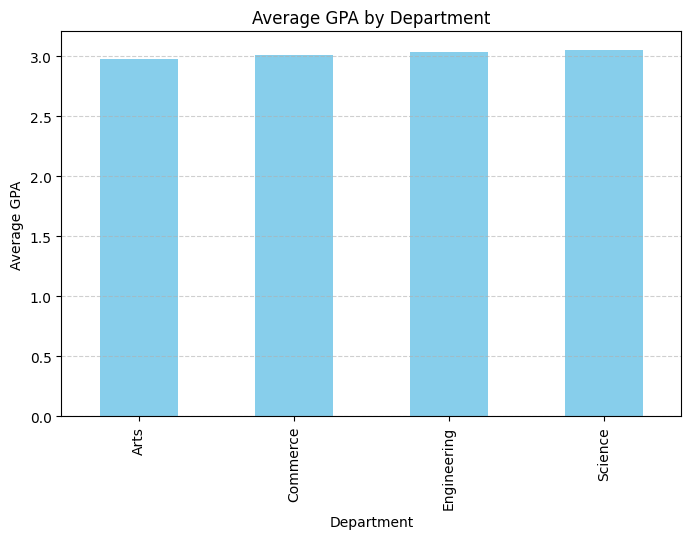


 Interpretation:
→ The bar plot shows the average GPA for each department.
→ Departments with higher bars indicate better academic performance on average.
→ This helps identify which department's students are achieving stronger GPAs.


In [14]:
plt.figure(figsize=(8, 5))
avg_gpa_by_dept = df.groupby('Department')['GPA'].mean().sort_values()
avg_gpa_by_dept.plot(kind='bar', color='skyblue')
plt.title('Average GPA by Department')
plt.ylabel('Average GPA')
plt.xlabel('Department')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print("\n Interpretation:")
print("→ The bar plot shows the average GPA for each department.\n"
      "→ Departments with higher bars indicate better academic performance on average.\n"
      "→ This helps identify which department's students are achieving stronger GPAs.")


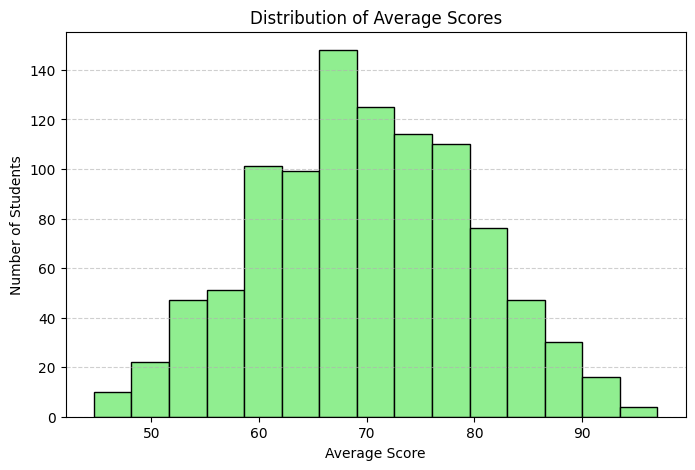


 Interpretation:
→ The histogram shows how average scores are distributed among students.
→ A bell-shaped or right-skewed distribution reveals the overall academic trend.
→ Most students cluster around the mid to high 70s, showing moderate performance.


In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df['Average_Score'], bins=15, color='lightgreen', edgecolor='black')
plt.title('Distribution of Average Scores')
plt.xlabel('Average Score')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print("\n Interpretation:")
print("→ The histogram shows how average scores are distributed among students.\n"
      "→ A bell-shaped or right-skewed distribution reveals the overall academic trend.\n"
      "→ Most students cluster around the mid to high 70s, showing moderate performance.")


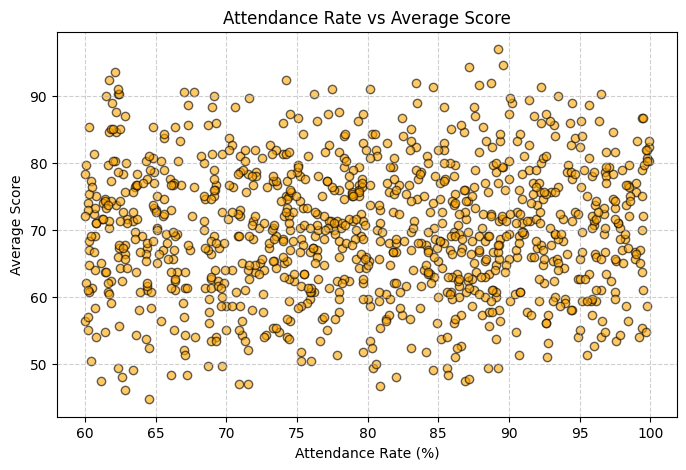


 Interpretation:
→ The scatter plot shows the relationship between attendance and academic performance.
→ A positive trend suggests that students with higher attendance generally achieve better scores.


In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Attendance_Rate'], df['Average_Score'], alpha=0.6, color='orange', edgecolors='black')
plt.title('Attendance Rate vs Average Score')
plt.xlabel('Attendance Rate (%)')
plt.ylabel('Average Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n Interpretation:")
print("→ The scatter plot shows the relationship between attendance and academic performance.\n"
      "→ A positive trend suggests that students with higher attendance generally achieve better scores.")